In [1]:
!pip install yfinance statsmodels hurst


In [2]:
# packages

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hurst import compute_Hc
from statsmodels.tsa.arima.model import ARIMA

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


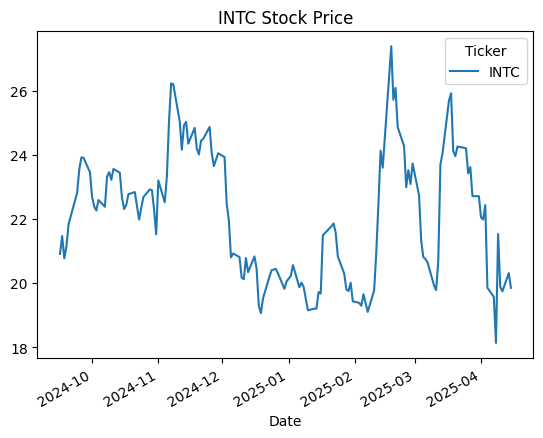

In [3]:
# data

ticker = "INTC"  # Apple Inc.
data = yf.download(ticker, start="2024-09-16", end="2025-04-16") # you can iterate for 6, 7 and 8 months
data['Close'].plot(title=f"{ticker} Stock Price")
plt.show()

In [4]:
# Hurst Exponent

def hurst_exponent(time_series):
    # Using the hurst package to compute the Hurst exponent
    H, c, data_reg = compute_Hc(time_series, kind='price', simplified=True)
    return H


hurst_value = hurst_exponent(data['Close'])
print(f"Hurst Exponent for {ticker}: {hurst_value}")

# Interpretation of the Hurst Exponent
if hurst_value < 0.5:
    print("The stock exhibits mean reversion.")
elif hurst_value > 0.5:
    print("The stock exhibits trending behavior.")
else:
    print("The stock behaves like a random walk.")

Hurst Exponent for INTC: 0.4180725510206965
The stock exhibits mean reversion.


**Conclusion:-**
We check for past 1 year, 2 year and 3 year. if all say mean reversion exsist, than opt for mean reversion.

**STATIONARITY CHECK:**

In [5]:
from statsmodels.tsa.stattools import adfuller
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA





In [6]:

# Step 2: Check if the data is stationary using the Augmented Dickey-Fuller (ADF) test
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] <= 0.05:
        print("The data is stationary.")
    else:
        print("The data is non-stationary, differencing needed.")

# Perform the ADF test on the closing prices
adf_test(data['Close'])

# Step 3: Apply Differencing if the data is non-stationary
# If the p-value from the ADF test is above 0.05, apply differencing
if adfuller(data['Close'])[1] > 0.05:
    data['Close_diff'] = data['Close'].diff().dropna()
    print(f"After differencing, the first few values of the differenced data are:\n{data['Close_diff'].head()}")
    # Plot the differenced data
    data['Close_diff'].plot(title=f"{ticker} Differenced Closing Price")
    plt.show()


ADF Statistic: -3.1805268378638094
p-value: 0.02113989628992484
The data is stationary.


**Checking Auto-correlation:**

In [ ]:
data['Close_diff'].dropna()
data['Close_diff']

,Close_diff
Date,
2020-01-02,NaN
2020-01-03,-0.706947
2020-01-06,0.573814
2020-01-07,-0.341354
2020-01-08,1.162071
...,...
2022-12-23,-0.365723
2022-12-27,-1.808975
2022-12-28,-3.944145


In [7]:

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
# Plot the ACF for the closing prices
plot_acf(data['Close_diff'], lags=50)  # You can adjust the number of lags
plt.show()

KeyError: 'Close_diff'

**Conclusion:- **

If this looks flat (no spikes), it confirms the series behaves like white noise — meaning ARIMA won't be helpful, and we may want to look into machine learning, regime switching, or other features like momentum or volatility, etc

**Deploying Simple Regime Switching Using Rolling Volatility:-**



We'll detect **two regimes** based on **rolling volatility**:

| Volatility Level | Assumed Regime |
|------------------|----------------|
| Low              | Mean Reversion |
| High             | Momentum       |





**Finding Regimes:**

In [8]:

# Step 1: Load stock data
data = yf.download('INTC', start='2024-08-16', end='2025-04-16') # you can iterate for 6, 7 and 8 months

# Step 2: Calculate daily returns
data['Returns'] = data['Close'].pct_change()

# Step 3: Rolling volatility (20-day)
data['Volatility'] = data['Returns'].rolling(window=20).std()

# Step 4: Define volatility threshold (e.g., median)
vol_threshold = data['Volatility'].median()

# Step 5: Regime labeling
data['Regime'] = ['Low Volatility' if v < vol_threshold else 'High Volatility'
                  for v in data['Volatility']]

# Optional: Encode as numeric for modeling (0 = Low, 1 = High)
data['Regime_Code'] = data['Regime'].map({'Low Volatility': 0, 'High Volatility': 1})



[*********************100%***********************]  1 of 1 completed


**Visulize regimes on price charts:**

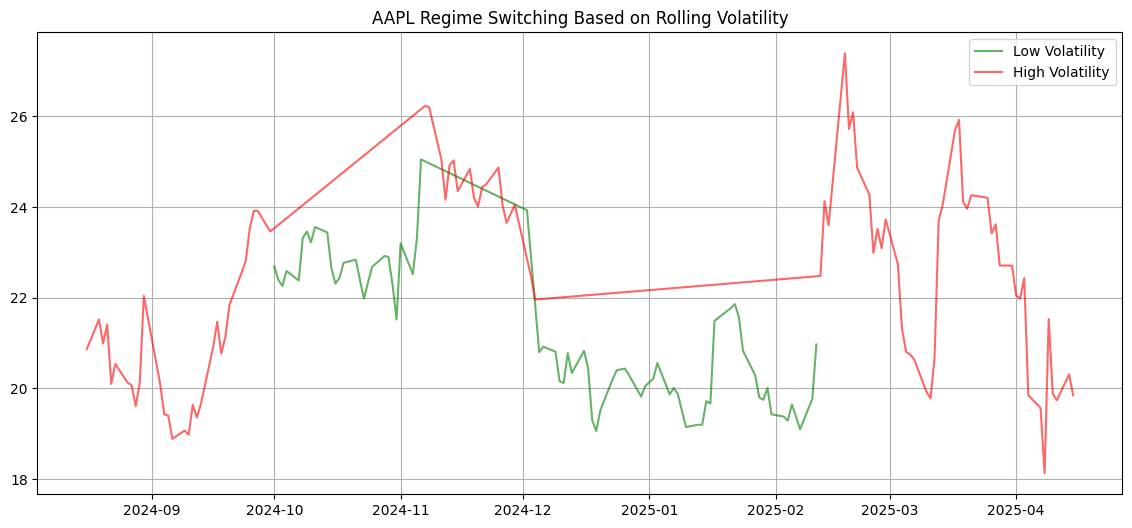

In [9]:
plt.figure(figsize=(14, 6))

for regime, color in zip(['Low Volatility', 'High Volatility'], ['green', 'red']):
    subset = data[data['Regime'] == regime]
    plt.plot(subset.index, subset['Close'], color=color, label=regime, alpha=0.6)

plt.title('AAPL Regime Switching Based on Rolling Volatility')
plt.legend()
plt.grid(True)
plt.show()


**This chart will show:**

Green = periods of low volatility (mean reversion mode)

Red = periods of high volatility (momentum mode)

**STATE TRANSITIONING PROBABILITIES WITH MARKOV APPROACH:-**


In [10]:
!pip install yfinance hmmlearn matplotlib seaborn


In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Download AAPL data
aapl = yf.download("NFLX", start="2024-09-16", end="2025-04-16") # You can iterate for 6,7 and 8 months

# Feature engineering
aapl['Return'] = aapl['Close'].pct_change()
aapl['Volatility'] = aapl['Return'].rolling(10).std()
aapl['Volume_Change'] = aapl['Volume'].pct_change()
aapl.dropna(inplace=True)

# Normalize features to improve convergence
scaler = StandardScaler()
X_scaled = scaler.fit_transform(aapl[['Return', 'Volatility', 'Volume_Change']])




[*********************100%***********************]  1 of 1 completed


In [12]:

# Multiple initializations to avoid local minima
best_score = -np.inf
best_model = None
for seed in range(50):  # Try 200 different initializations
    model = GaussianHMM(n_components=2, covariance_type="tied", n_iter=2000, random_state=seed)
    model.fit(X_scaled)
    score = model.score(X_scaled)
    if score > best_score:
        best_score = score
        best_model = model

# Best model
model = best_model


In [13]:

# Get hidden states (regimes)
hidden_states = model.predict(X_scaled)
aapl['Regime'] = hidden_states

# Map regimes to Bull and Bear
regime_stats = aapl.groupby('Regime')['Return'].mean()
bullish_state = regime_stats.idxmax()
bearish_state = regime_stats.idxmin()

# Label regimes as 'Bull' or 'Bear'
aapl['Regime_Label'] = aapl['Regime'].map({
    bullish_state: 'Bull',
    bearish_state: 'Bear'
})

# Get the transition matrix
trans_mat = model.transmat_
labels = {bullish_state: 'Bull', bearish_state: 'Bear'}
ordered_labels = [labels[i] for i in range(2)]

transition_text = ""
for i, from_label in enumerate(ordered_labels):
    for j, to_label in enumerate(ordered_labels):
        prob = trans_mat[i][j]
        transition_text += f"{from_label} → {to_label}: {prob:.2%}\n"


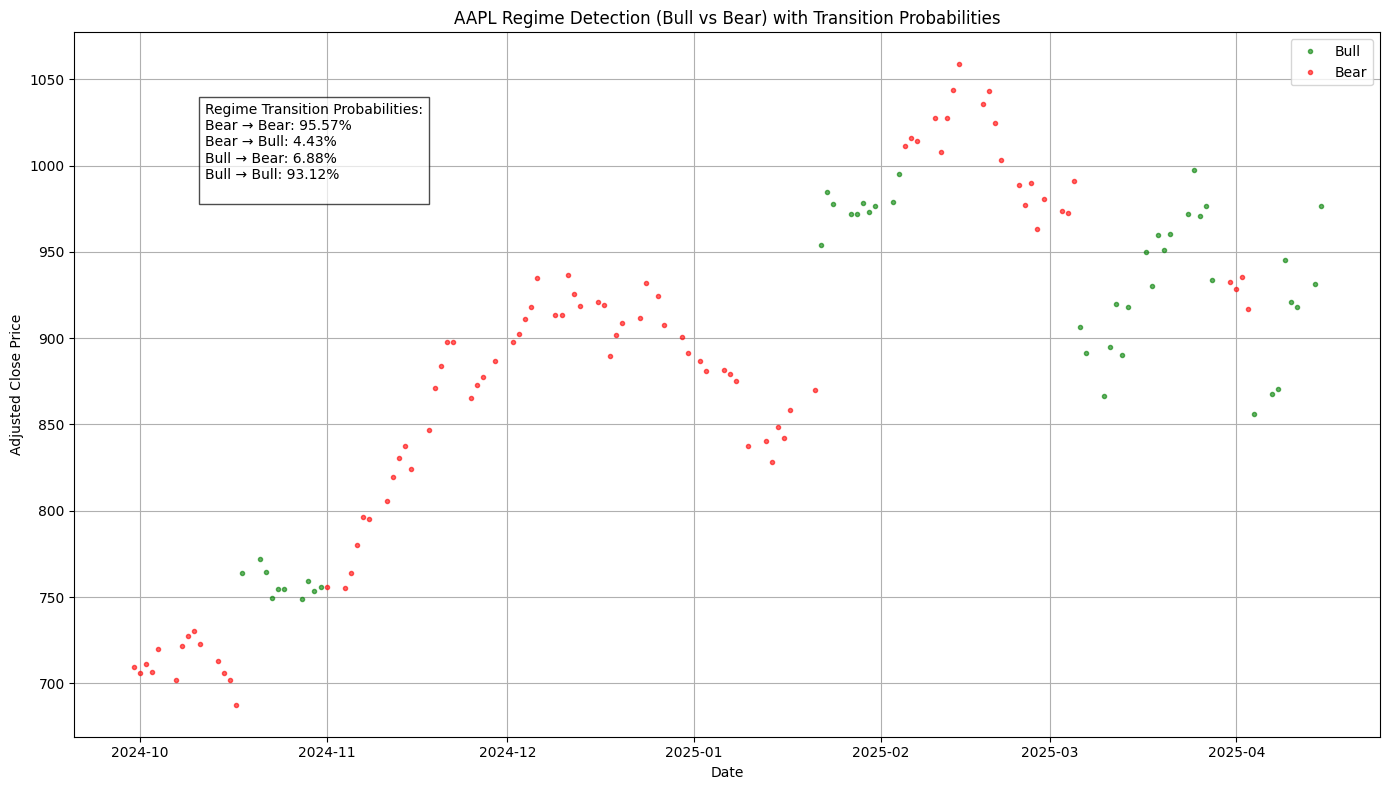

In [ ]:

# Plotting regime detection
plt.figure(figsize=(14, 8))
colors = {'Bull': 'green', 'Bear': 'red'}
for label in ['Bull', 'Bear']:
    regime_data = aapl[aapl['Regime_Label'] == label]
    plt.plot(regime_data.index, regime_data['Close'], '.', label=label, color=colors[label], alpha=0.6)

plt.title("AAPL Regime Detection (Bull vs Bear) with Transition Probabilities")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.grid(True)

# Add transition probabilities to plot
plt.figtext(0.15, 0.75, "Regime Transition Probabilities:\n" + transition_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()


**MAX RISK:-**

In [14]:
import yfinance as yf
import numpy as np
from scipy.stats import norm

def calculate_var_stop_loss(ticker: str, holding_days: int, position_type: str,
                            confidence_level: float = 0.95, max_stop_pct: float = 0.08):
    # Download past 1 year of daily data
    data = yf.download(ticker, period="1y", interval="1d")
    data.dropna(inplace=True)

    if len(data) < 2:
        raise ValueError("Not enough data to calculate returns.")

    # Calculate log returns and daily volatility
    data['LogReturn'] = np.log(data['Close'] / data['Close'].shift(1))
    daily_volatility = data['LogReturn'].std()

    # Z-score for confidence level
    z_score = norm.ppf(confidence_level)

    # Value at Risk percentage
    var_percent = z_score * daily_volatility * np.sqrt(holding_days)

    # Cap it at max allowed stop-loss (e.g. 8%)
    var_percent = min(var_percent, max_stop_pct)

    # Use latest closing price as entry
    entry_price = float(data['Close'].iloc[-1])

    # Calculate stop-loss
    if position_type.lower() == 'long':
        stop_loss_price = entry_price * (1 - var_percent)
    elif position_type.lower() == 'short':
        stop_loss_price = entry_price * (1 + var_percent)
    else:
        raise ValueError("Position type must be 'long' or 'short'.")

    return {
        "Stock": ticker,
        "Position": position_type,
        "Holding Days": holding_days,
        "Confidence Level": confidence_level,
        "VaR % (Capped)": round(var_percent * 100, 2),
        "Entry Price": round(entry_price, 2),
        "Stop Loss Price": round(stop_loss_price, 2)
    }

# Example usage
result = calculate_var_stop_loss("NFLX", 15, "long")
print(result)


[*********************100%***********************]  1 of 1 completed

{'Stock': 'NFLX', 'Position': 'long', 'Holding Days': 15, 'Confidence Level': 0.95, 'VaR % (Capped)': 8.0, 'Entry Price': 973.03, 'Stop Loss Price': 895.19}


**PORTFOLIO OPTIMIZATION:-**

**Diversification Check:-**

[*********************100%***********************]  11 of 11 completed


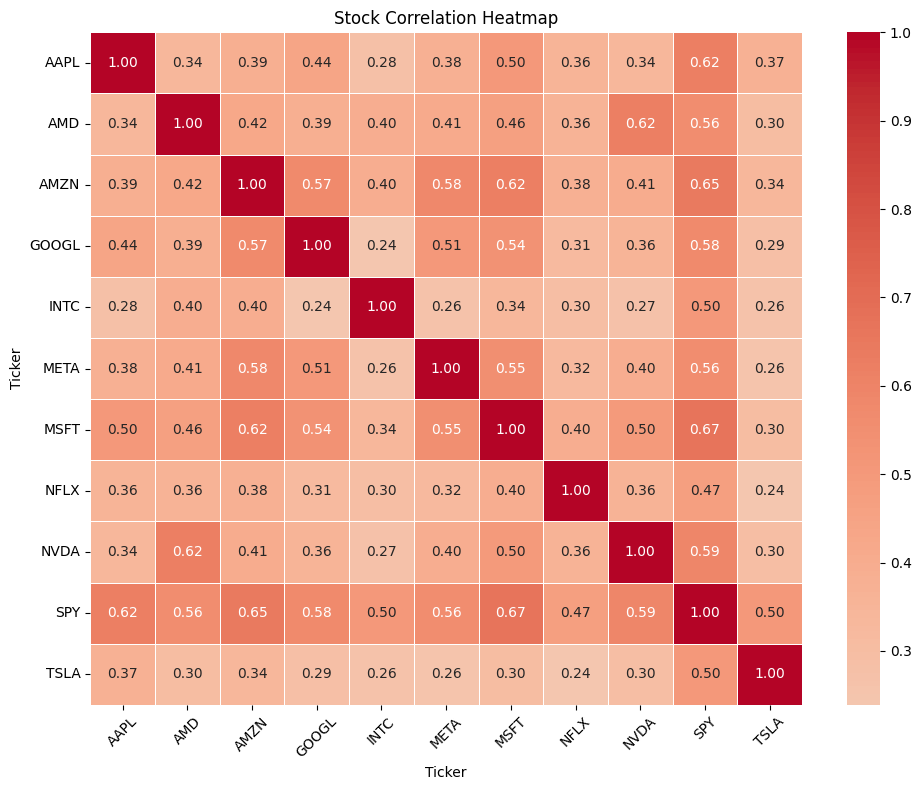

In [15]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of tickers
tickers = ["SPY", "AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "META", "NVDA", "NFLX", "AMD", "INTC"]

# Step 1: data (adjusted close prices)
data = yf.download(tickers, start="2023-01-01", end="2024-12-31")['Close']

# Step 2: daily returns
returns = data.pct_change().dropna()

# Step 3: Compute corr matrix
correlation_matrix = returns.corr()

# Step 4: heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5, fmt=".2f")
plt.title("Stock Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


[*********************100%***********************]  11 of 11 completed


📊 Maximally Diversified Subset (Mutual Corr ≤ 0.3):
- INTC
- NVDA
- TSLA


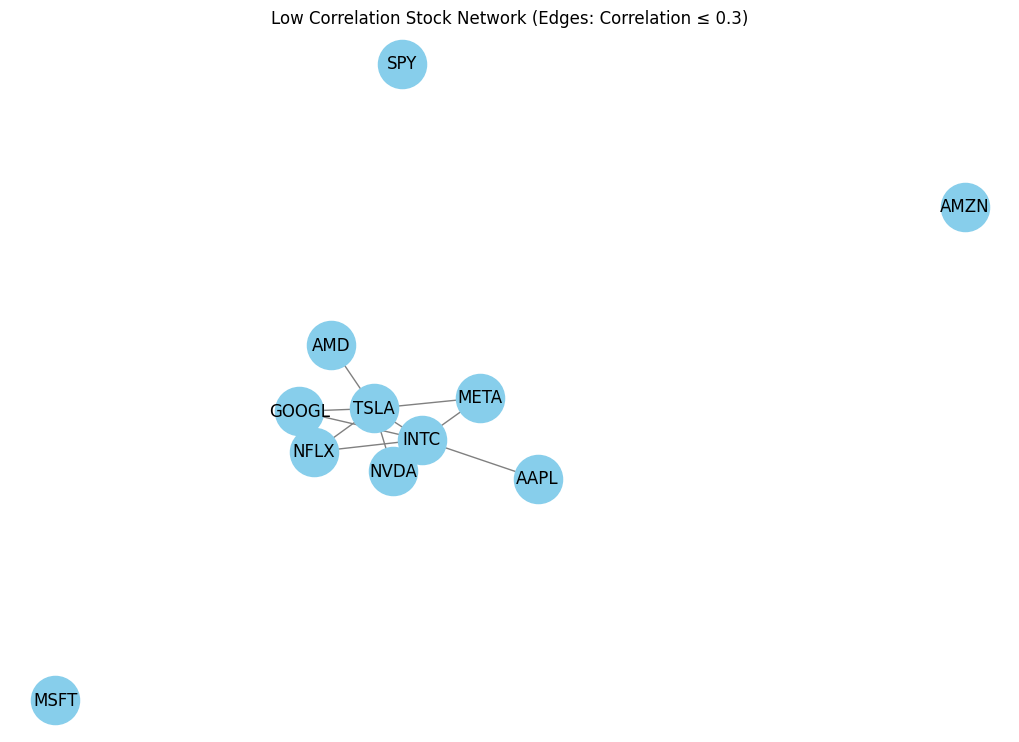

In [ ]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

# List of tickers
tickers = ["SPY", "AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "META", "NVDA", "NFLX", "AMD", "INTC"]

# Step 1: Download close prices
data = yf.download(tickers, start="2023-01-01", end="2024-12-31")['Close']
returns = data.pct_change().dropna()
correlation_matrix = returns.corr()

# Step 2: Build graphical topology to identify maximally diversified subsets
threshold = 0.3
G = nx.Graph()

# Add nodes
G.add_nodes_from(tickers)

# Add edges
for i in range(len(tickers)):
    for j in range(i + 1, len(tickers)):
        stock1 = tickers[i]
        stock2 = tickers[j]
        corr = correlation_matrix.loc[stock1, stock2]
        if abs(corr) <= threshold:
            G.add_edge(stock1, stock2)

# Step 3: Find largest clique
cliques = list(nx.find_cliques(G))
largest_clique = max(cliques, key=len)

# Step 4: results
print("📊 Maximally Diversified Subset (Mutual Corr ≤ 0.3):")
for stock in sorted(largest_clique):
    print(f"- {stock}")

# Optional: plot the network
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=1200, edge_color='gray')
plt.title("Low Correlation Stock Network (Edges: Correlation ≤ 0.3)")
plt.show()


**Mean variance optimization:-**

In [16]:
!pip install PyPortfolioOpt



In [17]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage
import yfinance as yf

# Tickers
tickers = ["AAPL", "GOOGL", "TSLA", "META", "NVDA", "NFLX", "AMD", "INTC"]

# Data
prices = yf.download(tickers, period="1y")["Close"]

# Calculate expected returns and sample covariance
mu = mean_historical_return(prices)
S = CovarianceShrinkage(prices).ledoit_wolf()

# Create the Efficient Frontier object (with long/short support)
ef = EfficientFrontier(mu, S, weight_bounds=(-1, 1))  # allow shorting

# Maximize Sharpe Ratio
weights = ef.max_sharpe()

# Display results
cleaned_weights = ef.clean_weights()
print("Optimal Long/Short Weights:")
print(cleaned_weights)

ef.portfolio_performance(verbose=True)


[*********************100%***********************]  8 of 8 completed


Optimal Long/Short Weights:
OrderedDict([('AAPL', 0.65866), ('AMD', -0.80702), ('GOOGL', 0.01663), ('INTC', -0.28779), ('META', -0.08149), ('NFLX', 1.0), ('NVDA', 0.18895), ('TSLA', 0.31206)])
Expected annual return: 143.7%
Annual volatility: 53.3%
Sharpe Ratio: 2.70


(1.4371007683511055, 0.5326216763010604, 2.698164254844925)

**SENTIMENTS SCORES:-(To adjust our portfolio)**

In [ ]:
!pip install textblob beautifulsoup4 requests

In [18]:
import requests
from bs4 import BeautifulSoup
from textblob import TextBlob

# 1. Scrape headlines from Yahoo Finance
def get_yahoo_news(ticker):
    url = f'https://finance.yahoo.com/quote/{ticker}?p={ticker}'
    headers = {'User-Agent': 'Mozilla/5.0'}
    page = requests.get(url, headers=headers)
    soup = BeautifulSoup(page.content, 'html.parser')
    headlines = soup.find_all('h3')
    return [h.get_text() for h in headlines]

# 2. Get average sentiment score
def get_sentiment_score(texts):
    sentiments = [TextBlob(text).sentiment.polarity for text in texts]
    return sum(sentiments) / len(sentiments) if sentiments else 0

# 3. Interpret score into trading signal
def interpret_sentiment(score):
    if score >= 0.5:
        return "Strong Bullish"
    elif score >= 0.1:
        return "Bullish"
    elif -0.1 < score < 0.1:
        return "Neutral"
    elif score <= -0.5:
        return "Strong Bearish"
    else:
        return "Bearish"

# 4. Main logic
def analyze_stock_sentiment(ticker):
    headlines = get_yahoo_news(ticker)
    if not headlines:
        return "No headlines found."

    score = get_sentiment_score(headlines)
    sentiment_label = interpret_sentiment(score)

    print(f"\n📈 Ticker: {ticker}")
    print(f"📰 Headlines analyzed: {len(headlines)}")
    print(f"📊 Sentiment Score: {score:.2f}")
    print(f"💡 Interpretation: {sentiment_label}\n")

# Run it
ticker = 'NFLX'  # You can change this to any stock ticker
analyze_stock_sentiment(ticker)



📈 Ticker: NFLX
📰 Headlines analyzed: 29
📊 Sentiment Score: 0.02
💡 Interpretation: Neutral

